In [153]:
import pandas as pd
import numpy as np

In [154]:
merged = pd.read_csv('../../../data/busan_youth_v3.csv')
# merged = pd.read_csv('../../../data/busan_youth_v3.csv', index_col='Unnamed: 0')
merged.head()

,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,제조업종사자수,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),전체산업종사자수(천명당),기업밀도,지역내총생산(십억원),청년_19_29_증감률(%),청년_30_39_증감률(%)
0,2016,강원특별자치도,1536.2750,22.40,0.0,57365.0,3023906.0,1444.0,0.012368,13.734520,388.413533,351.305988,44677.444,1.149646,-2.070627
1,2016,경기도,12509.4835,61.61,0.0,1276105.0,3328379.0,3925.0,0.006235,4.028943,383.915851,2230.077238,433443.961,1.820153,-0.773010
2,2016,경상남도,3348.2515,36.61,0.0,433488.0,3257296.0,1689.0,0.007168,5.764203,411.869001,652.882347,113497.638,-0.054546,-2.108272
3,2016,경상북도,2683.4775,26.10,0.0,328962.0,3326347.0,1035.0,0.014533,7.266690,404.936505,549.557763,112216.094,-0.105801,-2.177146
4,2016,광주광역시,1461.5310,46.68,0.0,85157.0,2994355.0,1284.0,0.012316,3.900020,400.597729,289.682121,39427.386,-0.390397,-3.492136


In [155]:
merged = merged.drop(columns=['전체산업종사자수(천명당)'])

In [156]:
merged.columns

Index(['연도', '행정구역', '연앙인구수(천명)', '재정자립도(%)', '통계방식변경', '제조업종사자수',
       '상용월평균급여(원)', '문화예술활동(건)', '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도',
       '지역내총생산(십억원)', '청년_19_29_증감률(%)', '청년_30_39_증감률(%)'],
      dtype='object')

In [157]:
merged['청년_19_29_증감률(%)']

0      1.149646
1      1.820153
2     -0.054546
3     -0.105801
4     -0.390397
         ...   
148   -5.046648
149   -5.533847
150   -5.538364
151   -2.439551
152   -4.867564
Name: 청년_19_29_증감률(%), Length: 153, dtype: float64

In [158]:
# 변수 분류
# 종속변수
y_cols = merged[['청년_19_29_증감률(%)', '청년_30_39_증감률(%)']]

# 독립변수
x_cols = merged[['제조업종사자수', '상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도']]

x_cols_control = merged[['제조업종사자수', '상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도', '통계방식변경']]


# 통제변수
meta_cols = merged[['연앙인구수(천명)', '재정자립도(%)', '지역내총생산(십억원)']]

# Group by
group_cols = merged[['연도', '행정구역']]


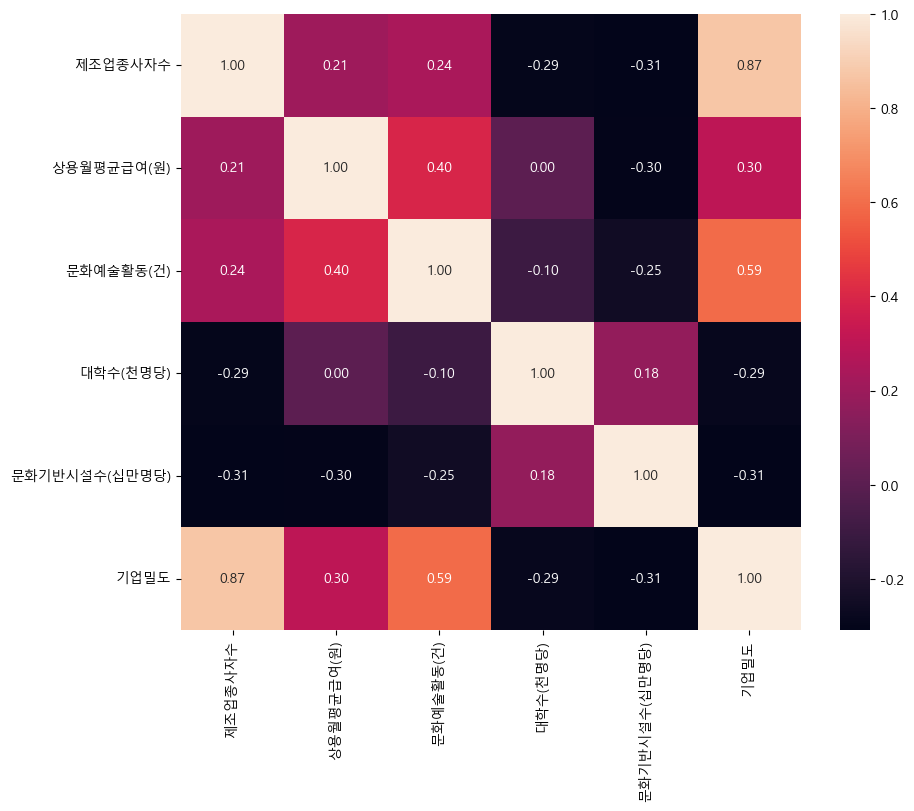

In [159]:
# 독립변수 상관관계 확인(다중공선성 문제 확인)

x_corr = x_cols.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows
plt.rcParams["axes.unicode_minus"] = False


plt.figure(figsize=(10, 8))
sns.heatmap(x_corr, annot=True, fmt=".2f")
plt.show()

In [160]:
# 1차 분산팽창계수 확인

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(x_cols)
vif_df = pd.DataFrame()
vif_df['feature'] = x_cols.columns
vif_df['VIF'] = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]

vif_df.sort_values('VIF', ascending=False)

,feature,VIF
5,기업밀도,12.105955
0,제조업종사자수,8.551690
2,문화예술활동(건),3.331428
1,상용월평균급여(원),1.273737
4,문화기반시설수(십만명당),1.221441
3,대학수(천명당),1.123544


In [161]:
# 기업밀도 = 제조업 규모 + 산업 집적 + 활동량을 거의 대리하는 변수 
# 기업밀도와 제조업종사자수 -> 분산팽창계수 높음
# 제조업종사자수 삭제

merged = merged.drop(columns=['제조업종사자수'])

In [162]:
# 2차 변수 분류
# 종속변수
y_cols = merged[['청년_19_29_증감률(%)', '청년_30_39_증감률(%)']]

# 독립변수
x_cols = merged[['상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도']]

x_cols_control = merged[['상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도', '통계방식변경']]


# 통제변수
meta_cols = merged[['연앙인구수(천명)', '재정자립도(%)', '지역내총생산(십억원)']]

# Group by
group_cols = merged[['연도', '행정구역']]

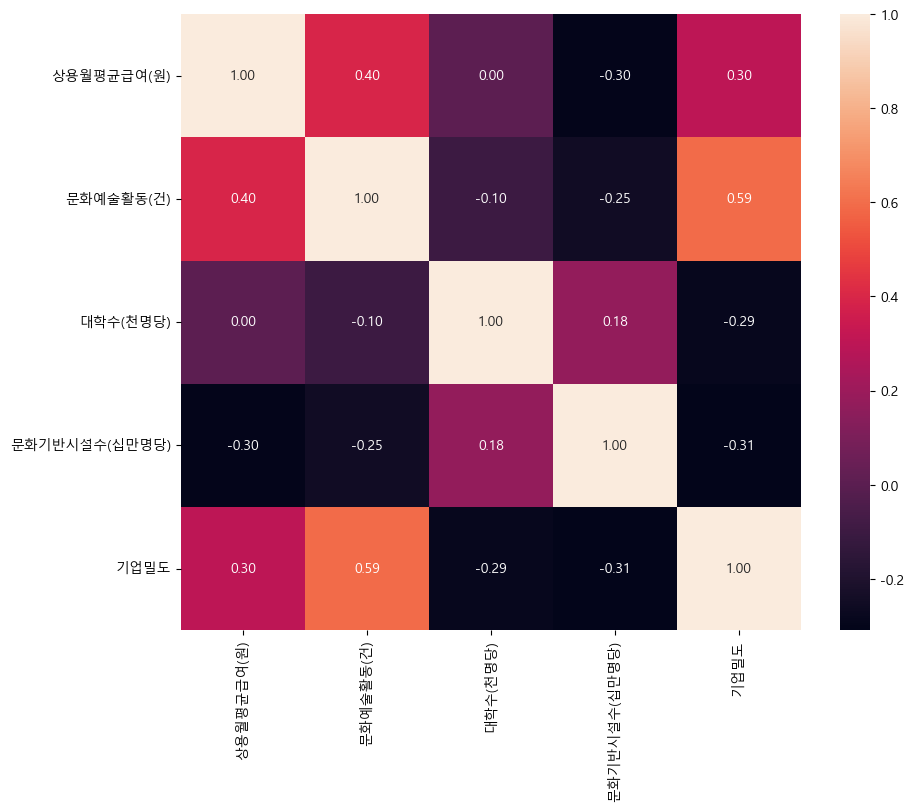

In [163]:
# 2차 독립변수 상관관계 확인(다중공선성 문제 확인)

x_corr = x_cols.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows
plt.rcParams["axes.unicode_minus"] = False


plt.figure(figsize=(10, 8))
sns.heatmap(x_corr, annot=True, fmt=".2f")
plt.show()

In [164]:
# 2차 분산팽창계수 확인

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(x_cols)
vif_df = pd.DataFrame()
vif_df['feature'] = x_cols.columns
vif_df['VIF'] = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]

vif_df.sort_values('VIF', ascending=False)

,feature,VIF
4,기업밀도,1.735434
1,문화예술활동(건),1.680152
0,상용월평균급여(원),1.268429
3,문화기반시설수(십만명당),1.186180
2,대학수(천명당),1.122210


In [165]:
merged.to_csv('data/busan_youth_v4.csv')

OSError: Cannot save file into a non-existent directory: 'data'